In [9]:
from typing import Union
import mne
import numpy as np

In [24]:
def analizar_edf(ruta_edf: str) -> None:
    # Cargar archivo EDF
    raw: mne.io.BaseRaw = mne.io.read_raw_edf(ruta_edf, preload=True)
    
    # Mostrar información general
    print("\n🔎 Información general:")
    print(raw.info)

    # Nombres de canales
    print("\n📺 Nombres de canales:")
    print(raw.ch_names)

    # Frecuencia de muestreo
    print("\n🕒 Frecuencia de muestreo (Hz):")
    print(raw.info['sfreq'])

    # Duración de la grabación
    print("\n⏱️ Duración (segundos):")
    print(raw.times[-1])

    # Número de muestras por canal
    print("\n🔢 Número de muestras por canal:")
    print(raw.n_times)

    # Mostrar una señal específica (canal 0)
    canal = 0
    data: np.ndarray
    times: np.ndarray
    data, times = raw[canal, :]  # canal, todas las muestras

    print(f"\n📊 Muestra de datos para el canal {raw.ch_names[canal]}:")
    print(f"Valores (primeros 10): {data[0][:10]}")
    print(f"Rango de valores: [{np.min(data)}, {np.max(data)}]")

    # Extra: graficar la señal de ese canal
    raw.plot(n_channels=30, duration=5, start=0, scalings='auto', title="Vista rápida del EDF")

Extracting EDF parameters from /home/dell/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 311249  =      0.000 ...  1244.996 secs...

🔎 Información general:
<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 30 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2012-01-01 00:00:00 UTC
 nchan: 30
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: aaaaaauj, sex: 2, last_name: aaaaaauj>
>

📺 Nombres de canales:
['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG A1-REF', 'EEG A2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF',

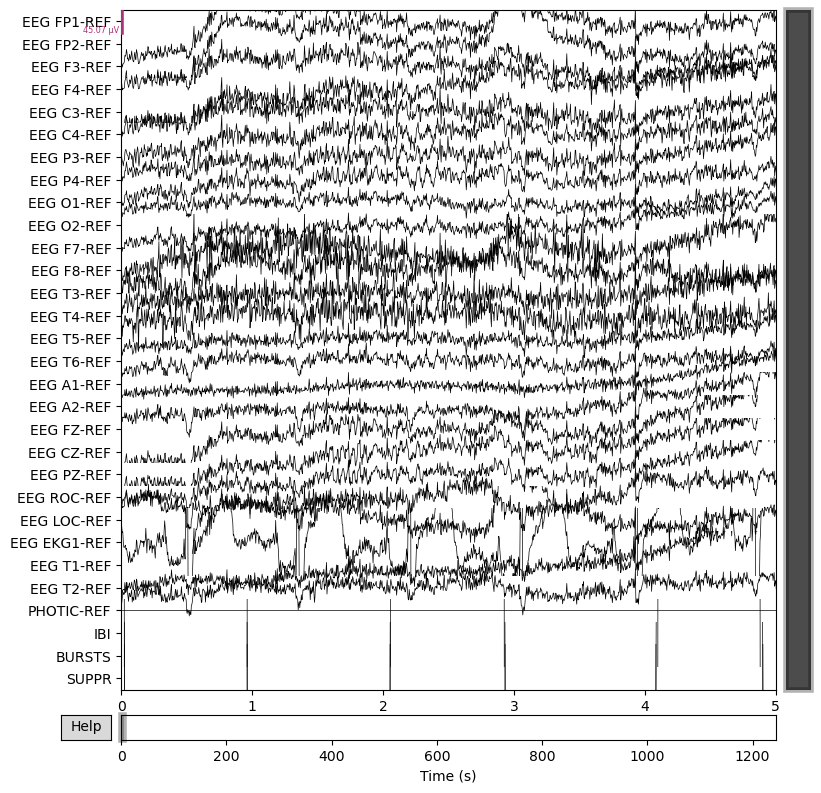

In [25]:
data_path = "../dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf"
analizar_edf(data_path)

In [26]:
import numpy as np
import os

def leer_valores_originales(filepath: str, n_canales: int) -> np.ndarray:
    header_bytes = 256 + 256 * n_canales
    file_size = os.path.getsize(filepath)
    data_bytes = file_size - header_bytes
    total_muestras = data_bytes // 2  # cada muestra ocupa 2 bytes
    total_filas = total_muestras // n_canales

    with open(filepath, 'rb') as f:
        f.seek(header_bytes)
        data = f.read(2 * total_filas * n_canales)
        valores = np.frombuffer(data, dtype='<i2')
        print(valores.shape)
        return valores.reshape(total_filas, n_canales).T  # [canales x muestras]

In [27]:
valores_crudos = leer_valores_originales(data_path, n_canales=30)

print("Forma:", valores_crudos.shape)  # (30, N)
print("Primeros 10 valores del canal 0:", valores_crudos[0][:10])

(8407470,)
Forma: (30, 280249)
Primeros 10 valores del canal 0: [-351 -271 -309 -218 -268 -128  248  326  372 -286]


In [28]:
valor_int16 = valores_crudos[0][0]
print("Valor int16 original:", valor_int16)

Valor int16 original: -351


In [15]:
import mne

raw = mne.io.read_raw_edf(data_path, preload=True)
info_canal = raw.info['chs'][0]  # canal 0

# Factores de escala
dmin = -info_canal['range'] / 2
dmax = +info_canal['range'] / 2
pmin = dmin * info_canal['cal']
pmax = dmax * info_canal['cal']

print(f"dmin: {dmin}, dmax: {dmax}, pmin: {pmin}, pmax: {pmax}")

Extracting EDF parameters from /home/dell/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 311249  =      0.000 ...  1244.996 secs...
dmin: -0.5, dmax: 0.5, pmin: -0.5, pmax: 0.5


In [16]:
def convertir_manual(valor: int, dmin: int, dmax: int, pmin: float, pmax: float) -> float:
    return (valor - dmin) * (pmax - pmin) / (dmax - dmin) + pmin

valor_fisico = convertir_manual(valor_int16, dmin, dmax, pmin, pmax)
print(f"Valor físico convertido (μV): {valor_fisico}")

Valor físico convertido (μV): -351.0


In [17]:
valor_mne = raw[0, 0][0][0]  # canal 0, muestra 0
print(f"Valor según MNE: {valor_mne}")

Valor según MNE: [-5.35548077e-05]


In [18]:
print("Valor int16:", valores_crudos[0][0])
print("Valor MNE crudo:", raw[0, 0][0][0])


Valor int16: -351
Valor MNE crudo: [-5.35548077e-05]


In [19]:
canal = 0
info_canal = raw.info['chs'][canal]

print("cal (ganancia):", info_canal['cal'])
print("range (rango digital):", info_canal['range'])

# Calculamos dmin y dmax
dmin = -info_canal['range'] / 2
dmax = +info_canal['range'] / 2
pmin = dmin * info_canal['cal']
pmax = dmax * info_canal['cal']

print(f"dmin: {dmin}, dmax: {dmax}")
print(f"pmin: {pmin}, pmax: {pmax}")


cal (ganancia): 1.0
range (rango digital): 1.0
dmin: -0.5, dmax: 0.5
pmin: -0.5, pmax: 0.5


In [32]:
dmin = -32768
dmax = 32767
pmin = -4999.84  # μV
pmax = 4999.847   # μV
valor_int16 = -351

valor_fisico_manual = (valor_int16 - dmin) * (pmax - pmin) / (dmax - dmin) + pmin
print(valor_fisico_manual)

-53.477697734036155


In [21]:
import pyedflib
data_path = "../dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf"

# Abrir el archivo EDF
f = pyedflib.EdfReader(data_path)

# Obtener parámetros del canal
dmin = f.getDigitalMinimum(0)
dmax = f.getDigitalMaximum(0)
pmin = f.getPhysicalMinimum(0)
pmax = f.getPhysicalMaximum(0)
print(f"dmin: {dmin}, dmax: {dmax}, pmin: {pmin}, pmax: {pmax}")

# Leer valores digitales del canal
digital_values = f.readSignal(0)
print(f"Primeros 10 valores digitales: {digital_values[:10]}")

# Convertir a valores físicos
physical_values = ((digital_values - dmin) / (dmax - dmin)) * (pmax - pmin) + pmin
print(f"Primeros 10 valores físicos: {physical_values[:10]}")
# Cerrar el archivo
f.close()
# Graficar los valores físicos

dmin: -32767, dmax: 32767, pmin: -4999.84, pmax: 4999.847
Primeros 10 valores digitales: [-53.5548077  -63.77818838 -71.25498917 -66.37218049 -64.23595169
 -63.16783729 -60.42125741 -48.21423571 -49.58752565 -46.53577023]
Primeros 10 valores físicos: [ -8.16830875  -9.72827162 -10.86913999 -10.12408309  -9.7981207
  -9.63513951  -9.216045    -7.35340277  -7.56295002  -7.09728946]


-5.35548077e-05 -6.37781884e-05 -7.12549892e-05 -6.63721805e-05
 -6.42359517e-05 -6.31678373e-05 -6.04212574e-05 -4.82142357e-05
 -4.95875257e-05 -4.65357702e-05

Leer header principal

In [22]:
def leer_header_general(filepath: str) -> str:
    with open(filepath, 'rb') as f:
        header = f.read(256)
    return header.decode('ascii', errors='replace')

texto_header = leer_header_general(data_path)
print(texto_header)

0       aaaaaauj F 01-JAN-0000 aaaaaauj Age:77                                          Startdate 01-JAN-2012 aaaaaauj_s004 XXX X                                       01.01.1200.00.007936                                                1245    1.00000030  


In [23]:
def leer_headers_canal(filepath: str, n_canales: int) -> list[str]:
    with open(filepath, 'rb') as f:
        f.seek(256)  # saltar header general
        headers = []
        for i in range(n_canales):
            canal_data = f.read(256)
            headers.append(canal_data.decode('ascii', errors='replace'))
    return headers

leer_header_generales = leer_headers_canal(data_path, n_canales=30)
print(leer_header_generales)  # Imprimir header del primer canal

['EEG FP1-REF     EEG FP2-REF     EEG F3-REF      EEG F4-REF      EEG C3-REF      EEG C4-REF      EEG P3-REF      EEG P4-REF      EEG O1-REF      EEG O2-REF      EEG F7-REF      EEG F8-REF      EEG T3-REF      EEG T4-REF      EEG T5-REF      EEG T6-REF      ', 'EEG A1-REF      EEG A2-REF      EEG FZ-REF      EEG CZ-REF      EEG PZ-REF      EEG ROC-REF     EEG LOC-REF     EEG EKG1-REF    EEG T1-REF      EEG T2-REF      PHOTIC-REF      IBI             BURSTS          SUPPR           Unknown                         ', '                                                Unknown                                                                         Unknown                                                                         Unknown                                         ', '                                Unknown                                                                         Unknown                                                                         Unknown                   